### 금융상품 갱신 여부 예측하는 DNN
Churn_Modelling.csv 파일을 보면, 고객 정보와 해당 고객이 금융상품을 갱신했는지 안했는지의 여부에 대한 데이터가 있다.

이 데이터를 가지고 갱신여부를 예측하는 딥러닝을 구성하시오.

- 통신사: 고객이 다음 달에 통신 서비스를 해지할지 예측
- OTT: 구독자가 구독을 취소할 가능성 예측
- 은행: 고객이 계좌나 금융상품을 이탈할 가능성 예측
- 쇼핑몰: 고객이 장기간 구매하지 않을 가능성 예측  
머신러닝 관점에서는 보통 이진 분류 문제이다.

# Neural Networks and Deep Learning

In [ ]:
import os
import warnings

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import tensorflow as tf
print(tf.__version__)

In [1]:
# Importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
import os

In [3]:
df = pd.read_csv('./datas_dnn/Churn_Modelling.csv')

In [4]:
df.isna().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [5]:
df.head(4)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0


In [6]:
y = df['Exited']

In [7]:
X = df.loc[ :  , 'CreditScore' : 'EstimatedSalary' ]

In [8]:
y.unique()

array([1, 0])

In [9]:
X.head(3)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57


In [10]:
X['Geography'].unique()

<StringArray>
['France', 'Spain', 'Germany']
Length: 3, dtype: str

In [11]:
X['Gender'].unique()

<StringArray>
['Female', 'Male']
Length: 2, dtype: str

In [12]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [13]:
ct = ColumnTransformer([ ('onehot', OneHotEncoder(), [1]), ('label', OrdinalEncoder(), [2])], remainder='passthrough' )

In [14]:
X_ct = ct.fit_transform(X)

In [15]:
X_ct[0, : ]

array([1.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
       6.1900000e+02, 4.2000000e+01, 2.0000000e+00, 0.0000000e+00,
       1.0000000e+00, 1.0000000e+00, 1.0000000e+00, 1.0134888e+05])

In [16]:
X.head(3)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57


In [17]:
X_ct

array([[1.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 1.0000000e+00,
        1.0000000e+00, 1.0134888e+05],
       [0.0000000e+00, 0.0000000e+00, 1.0000000e+00, ..., 0.0000000e+00,
        1.0000000e+00, 1.1254258e+05],
       [1.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 1.0000000e+00,
        0.0000000e+00, 1.1393157e+05],
       ...,
       [1.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        1.0000000e+00, 4.2085580e+04],
       [0.0000000e+00, 1.0000000e+00, 0.0000000e+00, ..., 1.0000000e+00,
        0.0000000e+00, 9.2888520e+04],
       [1.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 1.0000000e+00,
        0.0000000e+00, 3.8190780e+04]], shape=(10000, 12))

In [18]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [19]:
X_ct

array([[1.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 1.0000000e+00,
        1.0000000e+00, 1.0134888e+05],
       [0.0000000e+00, 0.0000000e+00, 1.0000000e+00, ..., 0.0000000e+00,
        1.0000000e+00, 1.1254258e+05],
       [1.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 1.0000000e+00,
        0.0000000e+00, 1.1393157e+05],
       ...,
       [1.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        1.0000000e+00, 4.2085580e+04],
       [0.0000000e+00, 1.0000000e+00, 0.0000000e+00, ..., 1.0000000e+00,
        0.0000000e+00, 9.2888520e+04],
       [1.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 1.0000000e+00,
        0.0000000e+00, 3.8190780e+04]], shape=(10000, 12))

In [20]:
mms = MinMaxScaler()

In [21]:
X_scaled = mms.fit_transform(X_ct)

In [22]:
X_scaled.shape

(10000, 12)

In [23]:
X_scaled[0, :]

array([1.        , 0.        , 0.        , 0.        , 0.538     ,
       0.32432432, 0.2       , 0.        , 0.        , 1.        ,
       1.        , 0.50673489])

In [24]:
X.head(1)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.0,1,1,1,101348.88


In [25]:
from sklearn.model_selection import train_test_split

In [26]:
X_scaled.shape

(10000, 12)

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, 
    test_size=0.2, 
    random_state=42)

In [28]:
# 모델링
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense


I0000 00:00:1788156406.882917   24991 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788156406.970320   24991 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788156408.694086   24991 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [29]:
X_train.shape

(8000, 12)

In [30]:
model = Sequential()

In [31]:
model.add(  keras.Input( shape=(12, ) )   )

In [32]:
model.add(  Dense(units= 6, activation='relu' )   )

I0000 00:00:1788156434.531337   24991 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5563 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [33]:

model.add( Dense(units= 8, activation='relu'))

In [34]:
model.add( Dense(units= 1, activation='sigmoid'))

In [35]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 6)              │            78 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 143 (572.00 B)

 Trainable params: 143 (572.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# compile

In [36]:
model.compile( optimizer='adam', loss= 'binary_crossentropy', metrics= ['accuracy']  )

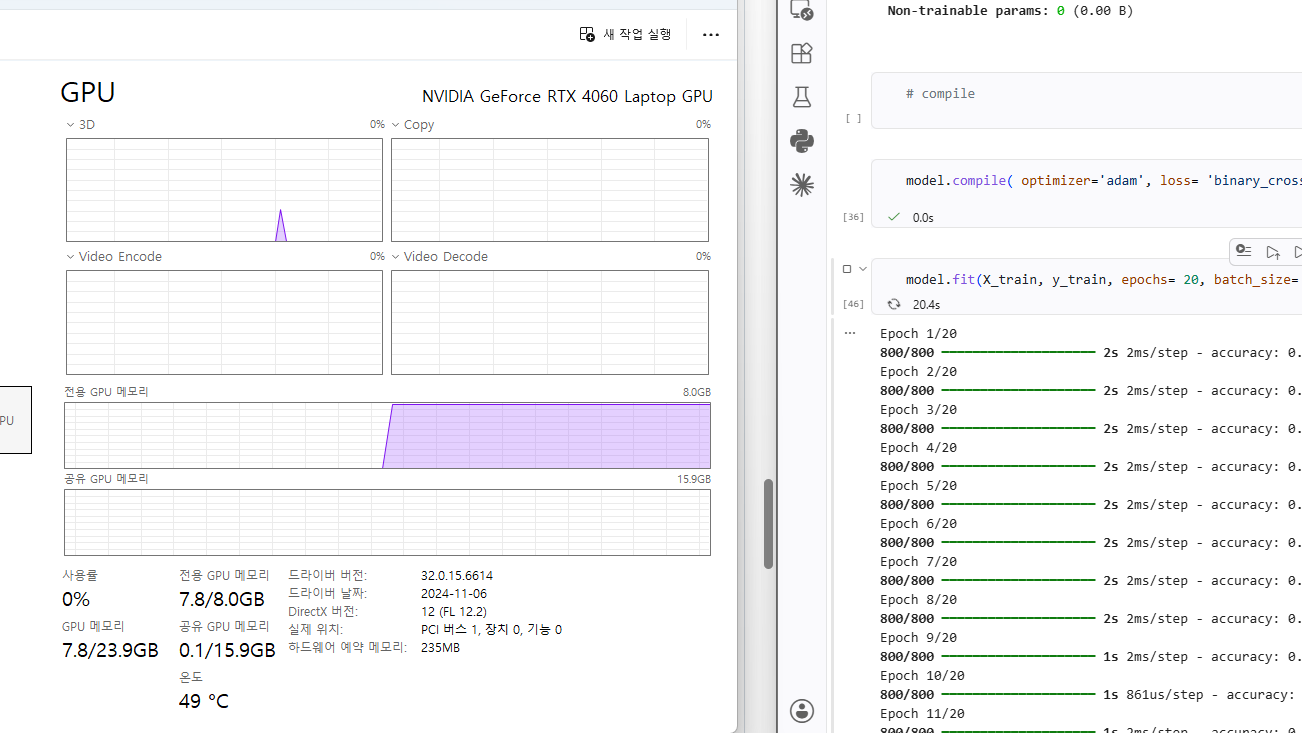

In [46]:
model.fit(X_train, y_train, epochs= 20, batch_size= 10 )

Epoch 1/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8611 - loss: 0.3409
Epoch 2/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8596 - loss: 0.3407
Epoch 3/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8581 - loss: 0.3402
Epoch 4/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8619 - loss: 0.3408
Epoch 5/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8599 - loss: 0.3404
Epoch 6/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8608 - loss: 0.3407
Epoch 7/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8624 - loss: 0.3391
Epoch 8/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8608 - loss: 0.3396
Epoch 9/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8625 - loss: 0.3406
Epoch 10/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 861us/step - accuracy: 0.8596 - loss: 0.3389
Epoch 11/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8600 - loss: 0.3389
Epoch 12/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/st

In [39]:
X_train.shape

(8000, 12)

In [40]:
8000 / 250

32.0

In [41]:
model.evaluate(X_test,y_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8580 - loss: 0.3472


[0.3471601903438568, 0.8579999804496765]

In [42]:
# 정확도 85% 모델완성.
y_pred = model.predict(X_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [43]:
y_test[:10]

6252    0
4684    0
1731    0
4742    0
4521    0
6340    0
576     0
5202    1
6363    0
439     0
Name: Exited, dtype: int64

In [44]:
y_pred[:10]

array([[0.06135227],
       [0.02476544],
       [0.14704807],
       [0.23977248],
       [0.0485805 ],
       [0.01756803],
       [0.2021941 ],
       [0.16429506],
       [0.35336226],
       [0.4991066 ]], dtype=float32)

In [47]:
y_pred = (y_pred > 0.5).astype(int)

In [48]:
y_pred[:5]

array([[0],
       [0],
       [0],
       [0],
       [0]])

In [49]:
y_pred = y_pred.flatten()

In [50]:
(y_test==y_pred).sum()/len(y_test)

np.float64(0.858)

# 다음 신규 데이터를 통해 분류해 보자
- Geography: France
- Credit Score: 600
- Gender: Male
- Age: 40
- Tenure: 3
- Balance: 60000
- Number of Products: 2
- Has Credit Card: Yes
- Is Active Member: Yes
- Estimated Salary: 50000

In [51]:
X.head(2)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58


In [52]:
new_data = [ {'CreditScore' : 600, 
              'Geography' : 'France' , 
              'Gender' : 'Male', 
              'Age': 40, 
              'Tenure' : 3, 
              'Balance' : 60000, 
              'NumOfProducts':2, 
              'HasCrCard' : 1, 
              'IsActiveMember' : 1,
              'EstimatedSalary' : 50000 } ]

In [53]:
df_new = pd.DataFrame(new_data)

In [54]:
df_new

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,600,France,Male,40,3,60000,2,1,1,50000


In [55]:
import joblib
import os

pre_path = './preprocessor'
os.makedirs(pre_path, exist_ok=True)

In [59]:
# column transformer 저장
joblib.dump(ct, f'{pre_path}/ct.pkl')

# min max scaler 저장
joblib.dump(mms, f'{pre_path}/mms.pkl')

['./preprocessor/mms.pkl']

In [61]:
loaded_ct = joblib.load(f'{pre_path}/ct.pkl')
loaded_mms = joblib.load(f'{pre_path}/mms.pkl')

new_data_ct = loaded_ct.transform(df_new)
new_data_mms = loaded_mms.transform(new_data_ct)

In [62]:
new_data_ct

array([[1.e+00, 0.e+00, 0.e+00, 1.e+00, 6.e+02, 4.e+01, 3.e+00, 6.e+04,
        2.e+00, 1.e+00, 1.e+00, 5.e+04]])

In [63]:
new_data_mms

array([[1.        , 0.        , 0.        , 1.        , 0.5       ,
        0.2972973 , 0.3       , 0.23914092, 0.33333333, 1.        ,
        1.        , 0.24996597]])

In [64]:
y_pred = model.predict( new_data_mms )

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step


In [65]:
y_pred[0][0]

np.float32(0.041259445)

In [66]:
(y_pred > 0.5).astype(int)

array([[0]])

In [67]:
# modes 폴더가 없으면 생성
model_path = './models'
os.makedirs(model_path, exist_ok=True)

In [68]:
model.save(f'{model_path}/churn_model.keras')

In [69]:
import keras
model = keras.models.load_model(f'{model_path}/churn_model.keras')
model.evaluate(X_test, y_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8640 - loss: 0.3439


[0.3439292907714844, 0.8640000224113464]

In [ ]:
# 학습 완료 했으면, gpu 메모리 해제, restart kernel

# 용어 정리
epoch

- 한 번의 epoch는 신경망에서 전체 데이터 셋에 대해 forward pass/backward pass 과정을 거친 것을 말함. 즉, 전체 데이터 셋에 대해 한 번 학습을 완료한 상태

batch_size

메모리의 한계와 속도 저하 때문에 대부분의 경우에는 한 번의 epoch에서 모든 데이터를 한꺼번에 집어넣을 수는 없습니다. 그래서 데이터를 나누어서 주게 되는데 이때 몇 번 나누어서 주는가를 iteration, 각 iteration마다 주는 데이터 사이즈를 batch size라고 합니다.